In [1]:
from google.colab import files

uploaded = files.upload()

print("Dataset uploaded successfully!")

Saving Retail_Sales_2000_Rows_Clean.csv to Retail_Sales_2000_Rows_Clean.csv
Dataset uploaded successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("Retail_Sales_2000_Rows_Clean.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2000, 19)


In [4]:
df.head()

,Order_ID,Date,Customer_ID,Gender,Age,City,Region,Store,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Mode,Customer_Rating,Delivery_Days
0,ORD100001,2024-01-01,CUST1218,Male,58,Mumbai,West,Online,Grocery,Coffee,5,371.68,0.174,1535.04,1295.35,239.69,Cash,4.7,6.0
1,ORD100002,2024-01-01,CUST1486,Male,24,Guntur,South,Online,Beauty,Perfume,3,1104.23,0.127,2891.98,1863.16,1028.82,UPI,3.4,2.0
2,ORD100003,2024-01-01,CUST1540,Male,31,Chennai,South,Store A,Home & Kitchen,Cookware Set,2,2447.67,0.006,4865.97,3286.05,1579.92,Debit Card,4.1,6.0
3,ORD100004,2024-01-02,CUST1130,Male,38,Vijayawada,South,Store A,Beauty,Face Wash,6,1033.56,0.231,4768.85,3075.91,1692.94,Debit Card,4.3,1.0
4,ORD100005,2024-01-02,CUST1066,Male,44,Chennai,South,Store D,Beauty,Lip Balm,5,782.32,0.213,3078.43,1968.67,1109.75,Cash,4.2,2.0


In [5]:
df.tail()

,Order_ID,Date,Customer_ID,Gender,Age,City,Region,Store,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Mode,Customer_Rating,Delivery_Days
1995,ORD101996,2025-12-29,CUST1113,Male,26,Chennai,South,Online,Electronics,Smartwatch,3,30501.95,0.128,79793.10,59154.83,20638.27,Credit Card,4.6,7.0
1996,ORD101997,2025-12-29,CUST1549,Female,46,Chennai,South,Online,Beauty,Face Wash,4,1610.54,0.037,6203.80,3990.96,2212.84,Credit Card,4.8,2.0
1997,ORD101998,2025-12-30,CUST1106,Female,43,Guntur,South,Store A,Electronics,Tablet,4,21333.68,0.138,73558.53,53912.73,19645.80,UPI,4.8,1.0
1998,ORD101999,2025-12-30,CUST1364,Female,55,Visakhapatnam,South,Store C,Beauty,Face Wash,2,1885.89,0.036,3636.00,2356.09,1279.90,Cash,4.1,5.0
1999,ORD102000,2025-12-31,CUST1021,Female,30,Pune,West,Store C,Home & Kitchen,Cookware Set,1,3813.24,0.153,3229.81,2224.91,1004.90,Net Banking,3.4,NaN


In [6]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 2000
Number of Columns: 19


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         2000 non-null   object 
 1   Date             2000 non-null   object 
 2   Customer_ID      2000 non-null   object 
 3   Gender           2000 non-null   object 
 4   Age              2000 non-null   int64  
 5   City             2000 non-null   object 
 6   Region           2000 non-null   object 
 7   Store            2000 non-null   object 
 8   Category         2000 non-null   object 
 9   Product          2000 non-null   object 
 10  Quantity         2000 non-null   int64  
 11  Unit_Price       2000 non-null   float64
 12  Discount         1990 non-null   float64
 13  Sales            2000 non-null   float64
 14  Cost             2000 non-null   float64
 15  Profit           2000 non-null   float64
 16  Payment_Mode     2000 non-null   object 
 17  Customer_Ratin

In [8]:
print(df.dtypes)

Order_ID            object
Date                object
Customer_ID         object
Gender              object
Age                  int64
City                object
Region              object
Store               object
Category            object
Product             object
Quantity             int64
Unit_Price         float64
Discount           float64
Sales              float64
Cost               float64
Profit             float64
Payment_Mode        object
Customer_Rating    float64
Delivery_Days      float64
dtype: object


In [9]:
df.describe()

,Age,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Customer_Rating,Delivery_Days
count,2000.000000,2000.000000,2000.00000,1990.000000,2000.000000,2000.000000,2000.000000,1980.000000,1984.000000
mean,34.984500,4.002500,6486.15344,0.125497,22237.769630,16491.824030,5745.945565,4.007273,4.008569
std,10.799981,2.013833,9910.21854,0.072767,40029.175584,30637.162376,9445.013679,0.539372,1.981362
min,18.000000,1.000000,50.00000,0.000000,93.900000,81.770000,12.130000,2.000000,1.000000
25%,27.000000,2.000000,934.32750,0.063000,2546.677500,1826.332500,618.872500,3.600000,2.000000
50%,35.000000,4.000000,1787.26500,0.124500,6032.120000,3919.595000,2148.980000,4.000000,4.000000
75%,43.000000,6.000000,4122.99000,0.190000,16659.540000,11488.572500,5173.947500,4.400000,6.000000
max,70.000000,7.000000,43426.70000,0.250000,254659.140000,202335.670000,62402.490000,5.000000,7.000000


In [10]:
missing_values = df.isnull().sum()

print(missing_values)

Order_ID            0
Date                0
Customer_ID         0
Gender              0
Age                 0
City                0
Region              0
Store               0
Category            0
Product             0
Quantity            0
Unit_Price          0
Discount           10
Sales               0
Cost                0
Profit              0
Payment_Mode        0
Customer_Rating    20
Delivery_Days      16
dtype: int64


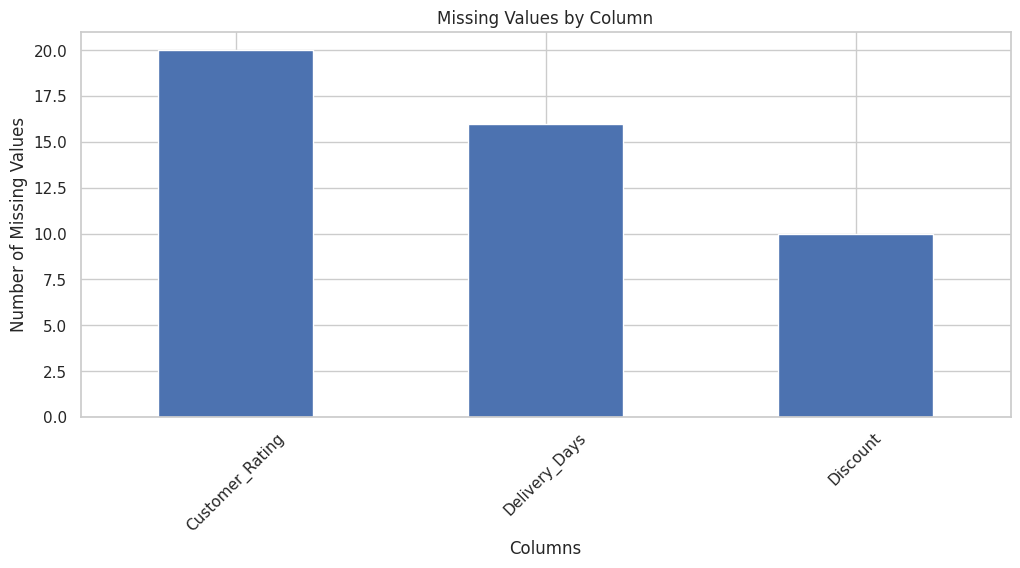

In [11]:
plt.figure(figsize=(12,5))

missing_values[missing_values > 0].sort_values(ascending=False).plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
df["Date"] = pd.to_datetime(df["Date"])

df["Discount"] = df["Discount"].fillna(df["Discount"].median())
df["Customer_Rating"] = df["Customer_Rating"].fillna(
    df["Customer_Rating"].median()
)
df["Delivery_Days"] = df["Delivery_Days"].fillna(
    df["Delivery_Days"].median()
)

df = df.drop_duplicates()

print("Data cleaning completed!")
print("Shape:", df.shape)

Data cleaning completed!
Shape: (2000, 19)


In [14]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(list(numerical_columns))

Numerical Columns:
['Age', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Cost', 'Profit', 'Customer_Rating', 'Delivery_Days']


In [15]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['Order_ID', 'Customer_ID', 'Gender', 'City', 'Region', 'Store', 'Category', 'Product', 'Payment_Mode']


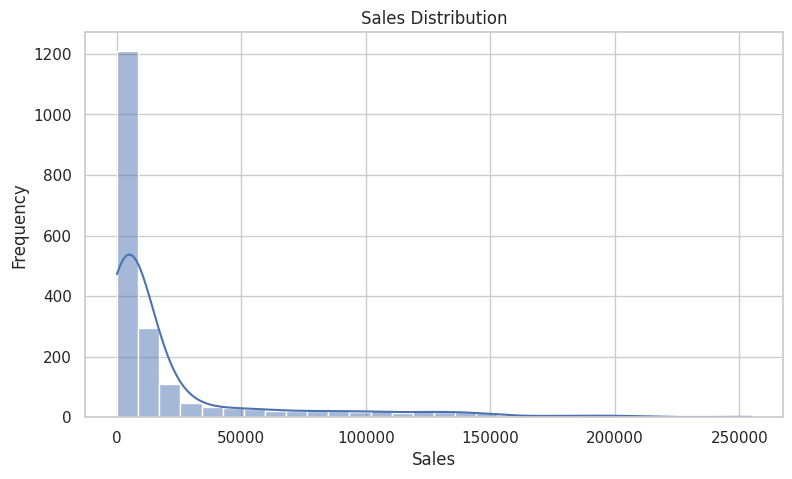

In [16]:
plt.figure(figsize=(9,5))

sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

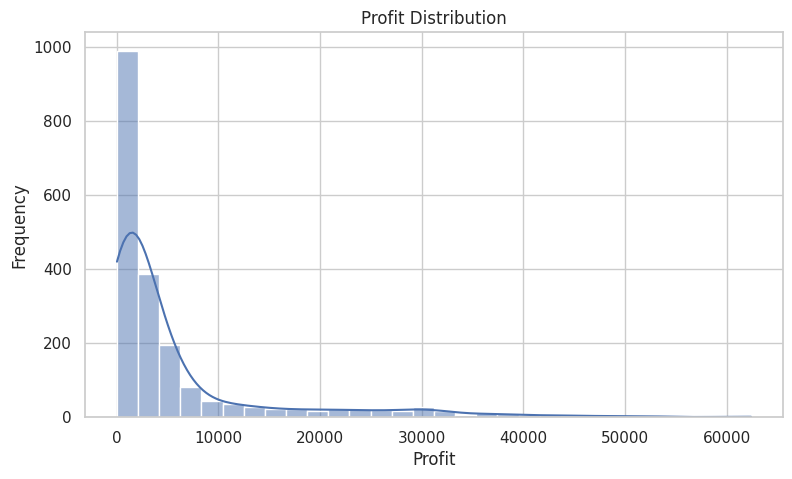

In [17]:
plt.figure(figsize=(9,5))

sns.histplot(df["Profit"], bins=30, kde=True)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

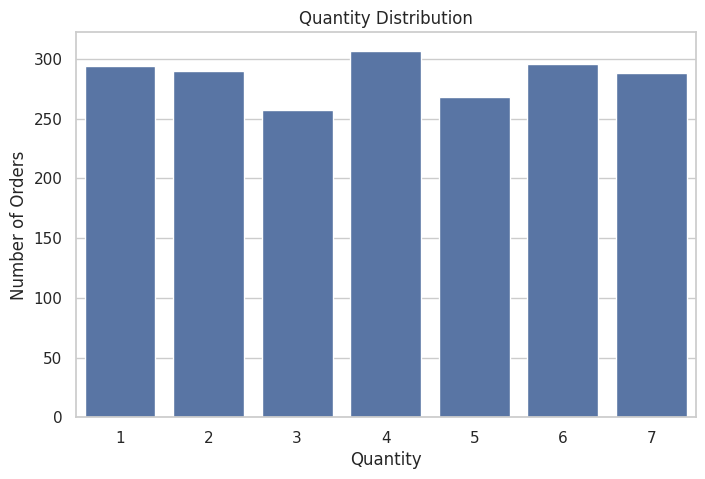

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(x="Quantity", data=df)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")
plt.show()

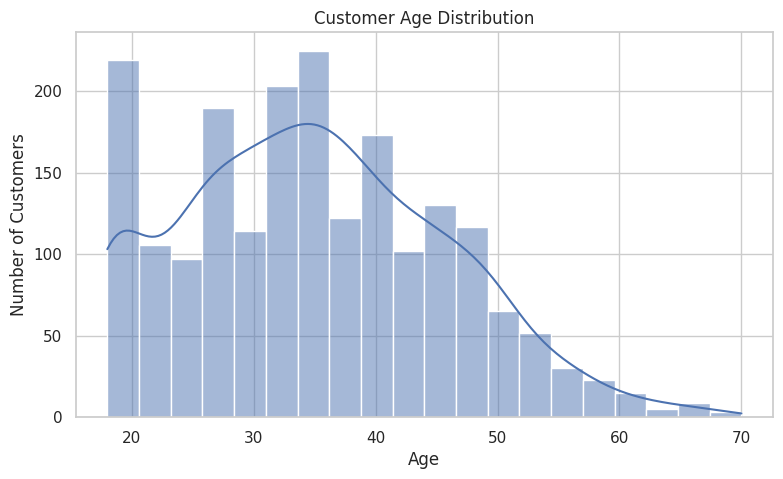

In [19]:
plt.figure(figsize=(9,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

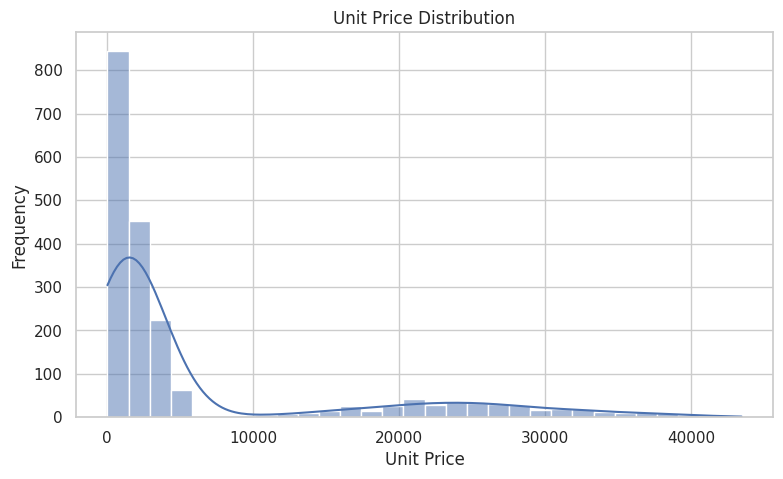

In [20]:
plt.figure(figsize=(9,5))

sns.histplot(df["Unit_Price"], bins=30, kde=True)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

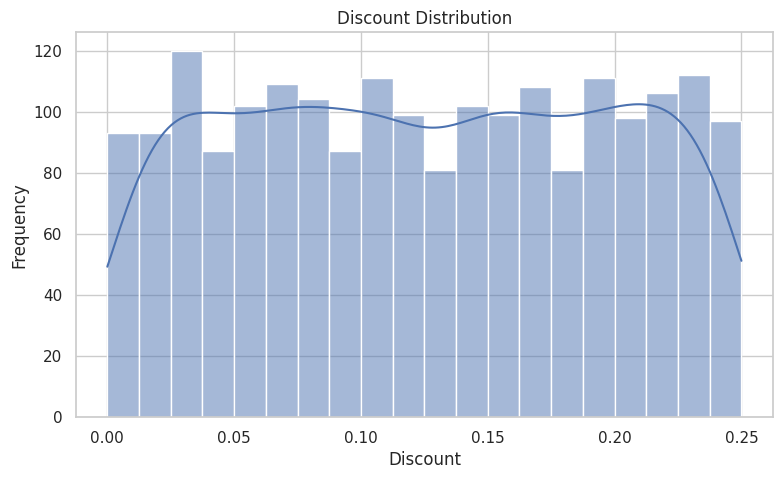

In [21]:
plt.figure(figsize=(9,5))

sns.histplot(df["Discount"], bins=20, kde=True)

plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

In [22]:
numeric_data = df.select_dtypes(include=np.number)

mean_values = numeric_data.mean()

print("MEAN")
print("-----")
print(mean_values)

MEAN
-----
Age                   34.984500
Quantity               4.002500
Unit_Price          6486.153440
Discount               0.125492
Sales              22237.769630
Cost               16491.824030
Profit              5745.945565
Customer_Rating        4.007200
Delivery_Days          4.008500
dtype: float64


In [23]:
median_values = numeric_data.median()

print("MEDIAN")
print("------")
print(median_values)

MEDIAN
------
Age                  35.0000
Quantity              4.0000
Unit_Price         1787.2650
Discount              0.1245
Sales              6032.1200
Cost               3919.5950
Profit             2148.9800
Customer_Rating       4.0000
Delivery_Days         4.0000
dtype: float64


In [24]:
mode_values = numeric_data.mode().iloc[0]

print("MODE")
print("----")
print(mode_values)

MODE
----
Age                 18.00
Quantity             4.00
Unit_Price          50.00
Discount             0.17
Sales               93.90
Cost               753.33
Profit              49.66
Customer_Rating      4.00
Delivery_Days        5.00
Name: 0, dtype: float64


In [25]:
variance_values = numeric_data.var()

print("VARIANCE")
print("--------")
print(variance_values)

VARIANCE
--------
Age                1.166396e+02
Quantity           4.055522e+00
Unit_Price         9.821243e+07
Discount           5.268549e-03
Sales              1.602335e+09
Cost               9.386357e+08
Profit             8.920828e+07
Customer_Rating    2.880122e-01
Delivery_Days      3.894375e+00
dtype: float64


In [27]:
std_values = numeric_data.std()

print("STANDARD DEVIATION")
print("------------------")
print(std_values)

STANDARD DEVIATION
------------------
Age                   10.799981
Quantity               2.013833
Unit_Price          9910.218540
Discount               0.072585
Sales              40029.175584
Cost               30637.162376
Profit              9445.013679
Customer_Rating        0.536668
Delivery_Days          1.973417
dtype: float64


In [28]:
Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)

IQR = Q3 - Q1

print("IQR (Interquartile Range)")
print("-------------------------")
print(IQR)

IQR (Interquartile Range)
-------------------------
Age                   16.0000
Quantity               4.0000
Unit_Price          3188.6625
Discount               0.1270
Sales              14112.8625
Cost                9662.2400
Profit              4555.0750
Customer_Rating        0.8000
Delivery_Days          4.0000
dtype: float64


In [30]:
statistical_summary = pd.DataFrame({
    "Mean": numeric_data.mean(),
    "Median": numeric_data.median(),
    "Mode": numeric_data.mode().iloc[0],
    "Variance": numeric_data.var(),
    "Standard Deviation": numeric_data.std(),
    "Minimum": numeric_data.min(),
    "Q1": numeric_data.quantile(0.25),
    "Q3": numeric_data.quantile(0.75),
    "Maximum": numeric_data.max(),
    "IQR": numeric_data.quantile(0.75) - numeric_data.quantile(0.25)
})

statistical_summary

,Mean,Median,Mode,Variance,Standard Deviation,Minimum,Q1,Q3,Maximum,IQR
Age,34.984500,35.0000,18.00,1.166396e+02,10.799981,18.00,27.0000,43.0000,70.00,16.0000
Quantity,4.002500,4.0000,4.00,4.055522e+00,2.013833,1.00,2.0000,6.0000,7.00,4.0000
Unit_Price,6486.153440,1787.2650,50.00,9.821243e+07,9910.218540,50.00,934.3275,4122.9900,43426.70,3188.6625
Discount,0.125492,0.1245,0.17,5.268549e-03,0.072585,0.00,0.0630,0.1900,0.25,0.1270
Sales,22237.769630,6032.1200,93.90,1.602335e+09,40029.175584,93.90,2546.6775,16659.5400,254659.14,14112.8625
Cost,16491.824030,3919.5950,753.33,9.386357e+08,30637.162376,81.77,1826.3325,11488.5725,202335.67,9662.2400
Profit,5745.945565,2148.9800,49.66,8.920828e+07,9445.013679,12.13,618.8725,5173.9475,62402.49,4555.0750
Customer_Rating,4.007200,4.0000,4.00,2.880122e-01,0.536668,2.00,3.6000,4.4000,5.00,0.8000
Delivery_Days,4.008500,4.0000,5.00,3.894375e+00,1.973417,1.00,2.0000,6.0000,7.00,4.0000


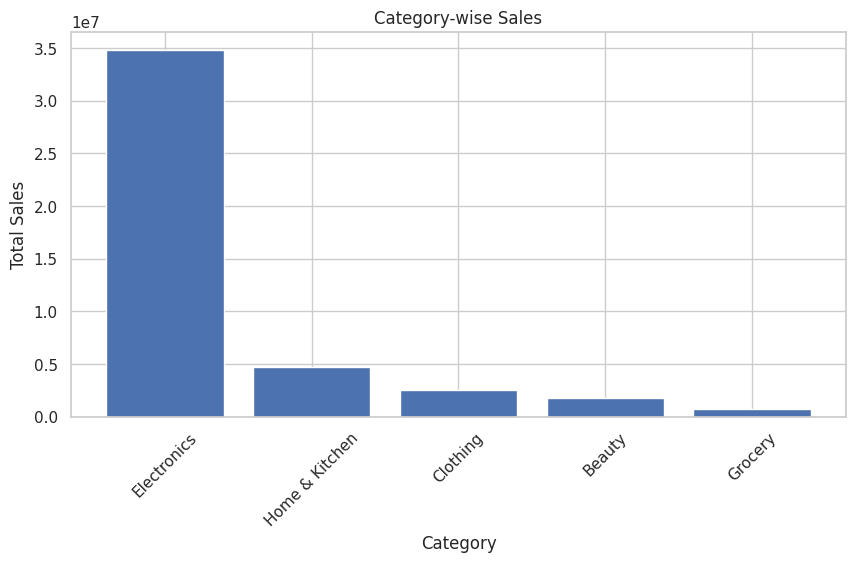

In [31]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(category_sales.index, category_sales.values)

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

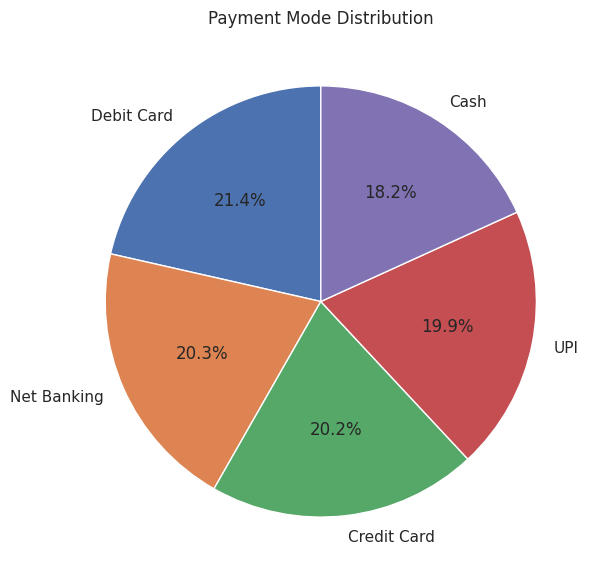

In [33]:
payment_count = df["Payment_Mode"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    payment_count.values,
    labels=payment_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Mode Distribution")
plt.show()

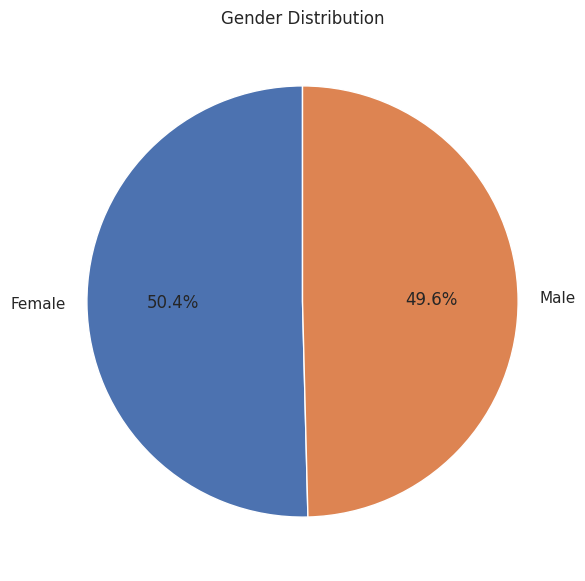

In [34]:
gender_count = df["Gender"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.show()

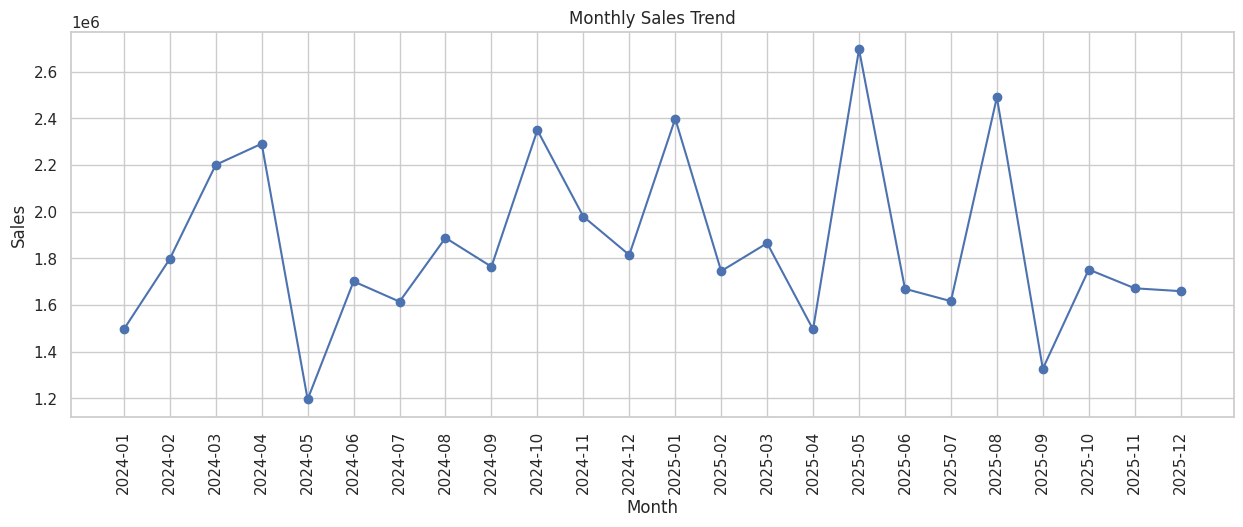

In [35]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(15,5))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

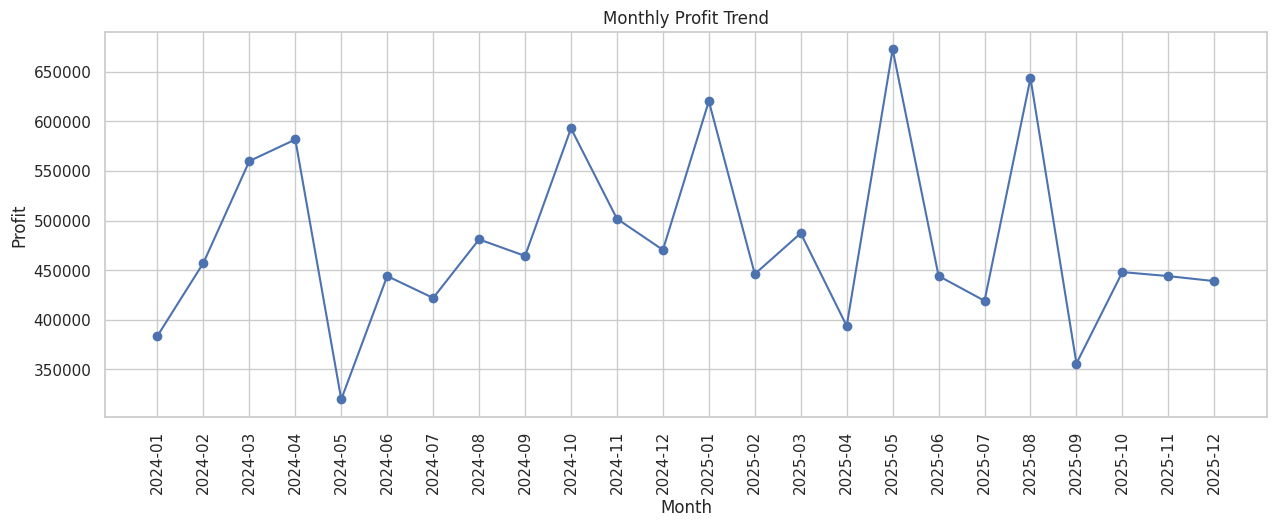

In [36]:
monthly_profit = df.groupby("Month")["Profit"].sum()

plt.figure(figsize=(15,5))
plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

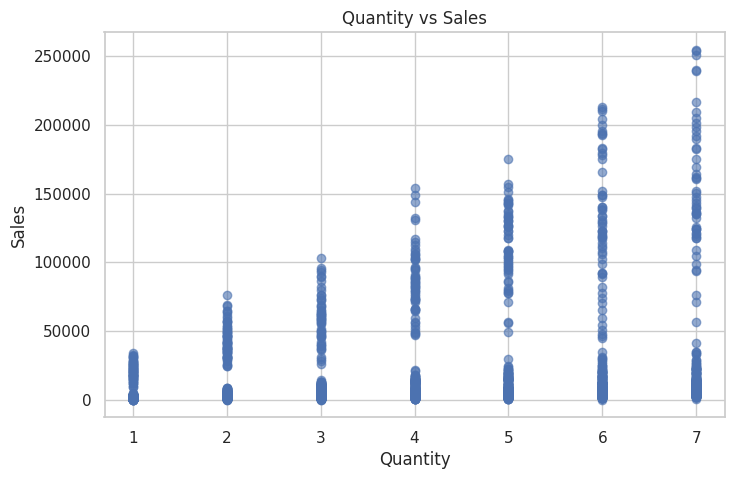

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Quantity"],
    df["Sales"],
    alpha=0.6
)

plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

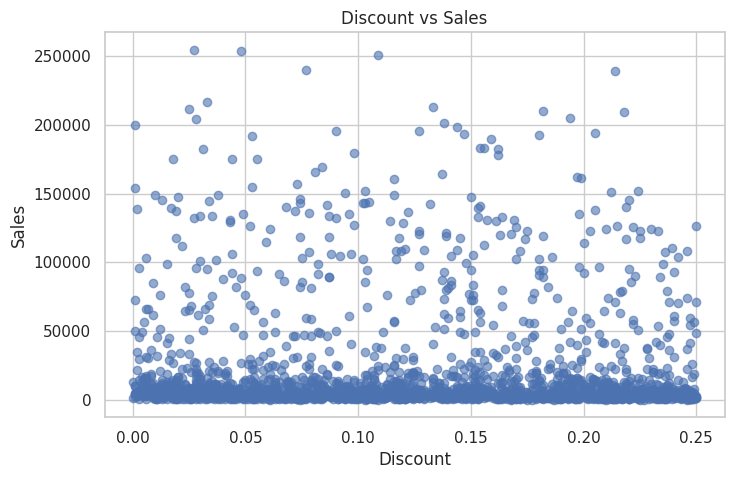

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Discount"],
    df["Sales"],
    alpha=0.6
)

plt.title("Discount vs Sales")
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

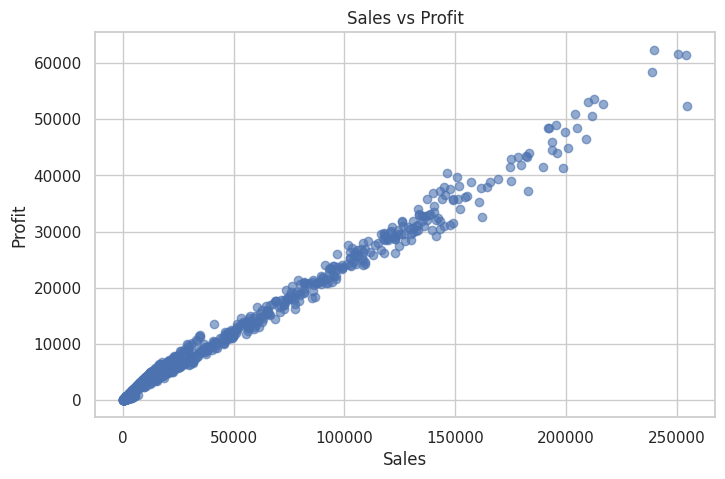

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.6
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

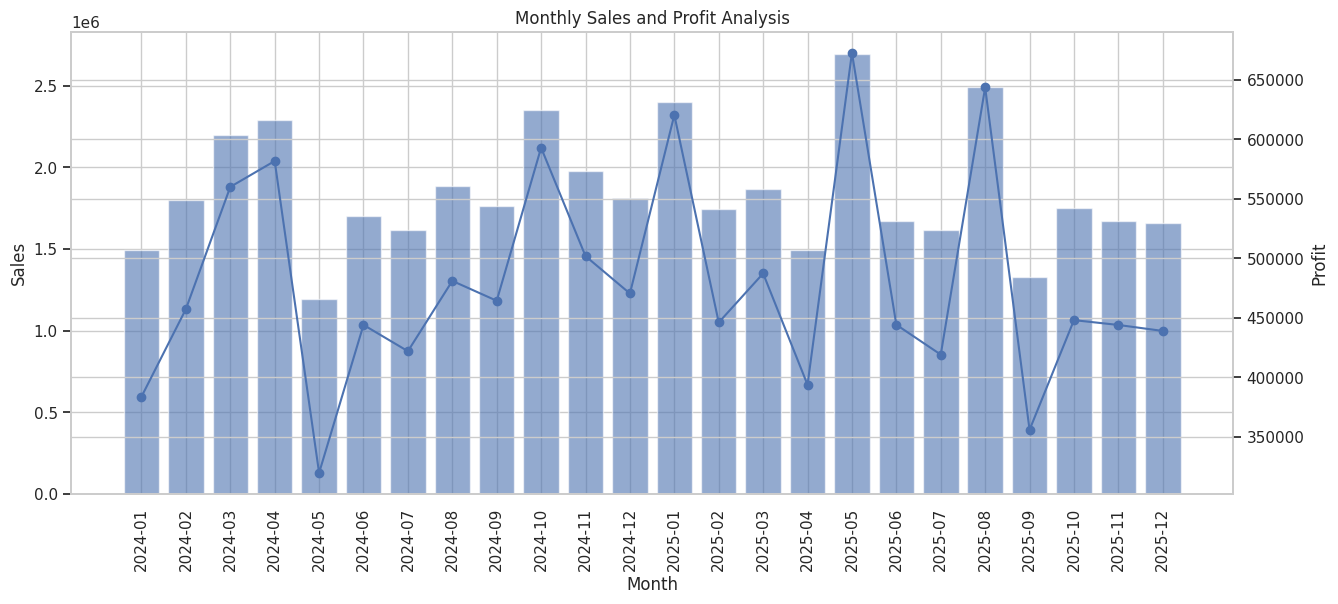

In [41]:
monthly_data = df.groupby("Month")[["Sales", "Profit"]].sum()

fig, ax1 = plt.subplots(figsize=(15,6))

ax1.bar(
    monthly_data.index,
    monthly_data["Sales"],
    alpha=0.6
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Sales")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    monthly_data.index,
    monthly_data["Profit"],
    marker="o"
)

ax2.set_ylabel("Profit")

plt.title("Monthly Sales and Profit Analysis")
plt.show()

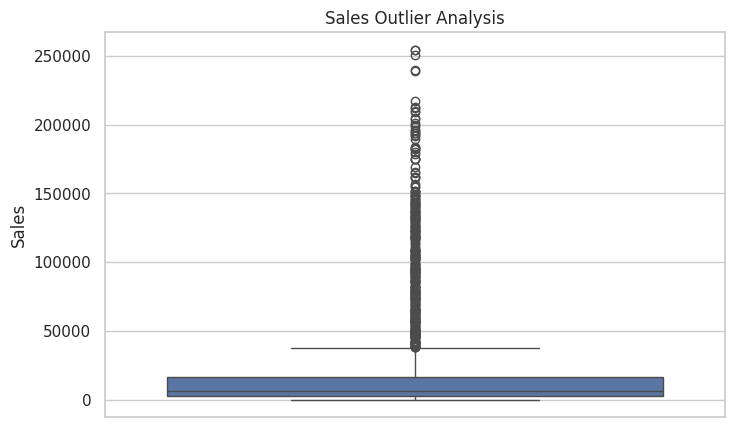

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Sales"])

plt.title("Sales Outlier Analysis")
plt.ylabel("Sales")

plt.show()

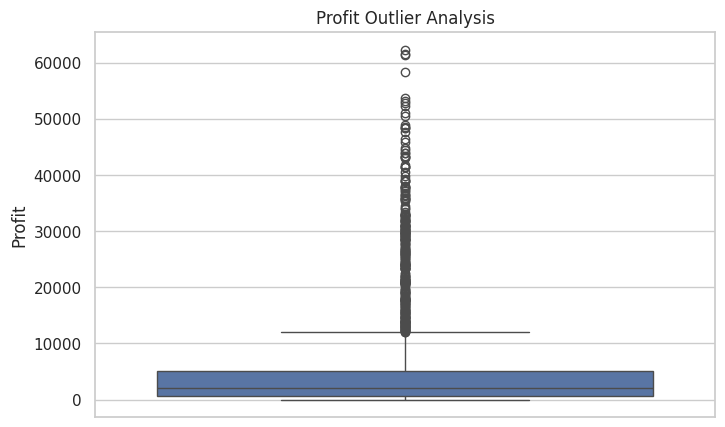

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Profit"])

plt.title("Profit Outlier Analysis")
plt.ylabel("Profit")

plt.show()

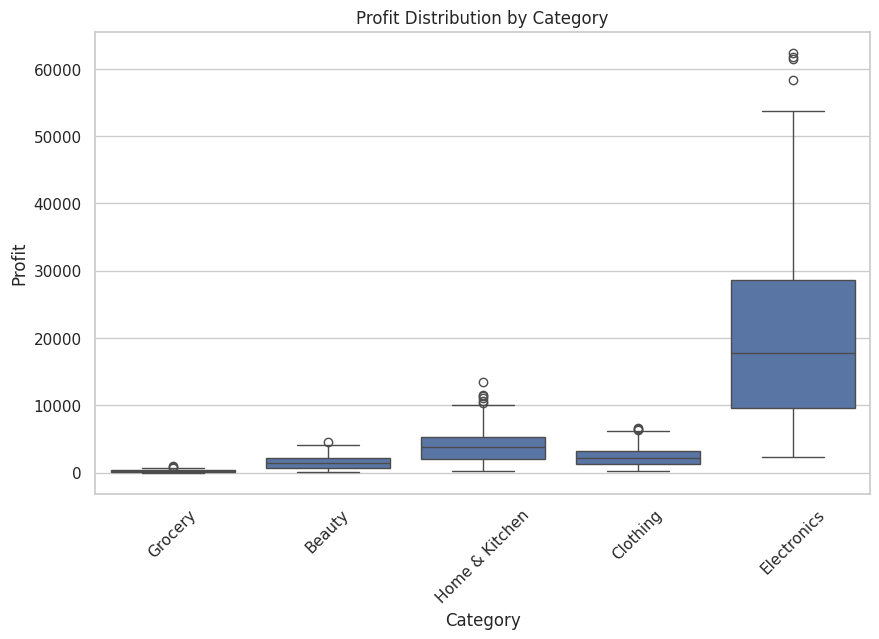

In [44]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Category",
    y="Profit"
)

plt.title("Profit Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)

plt.show()

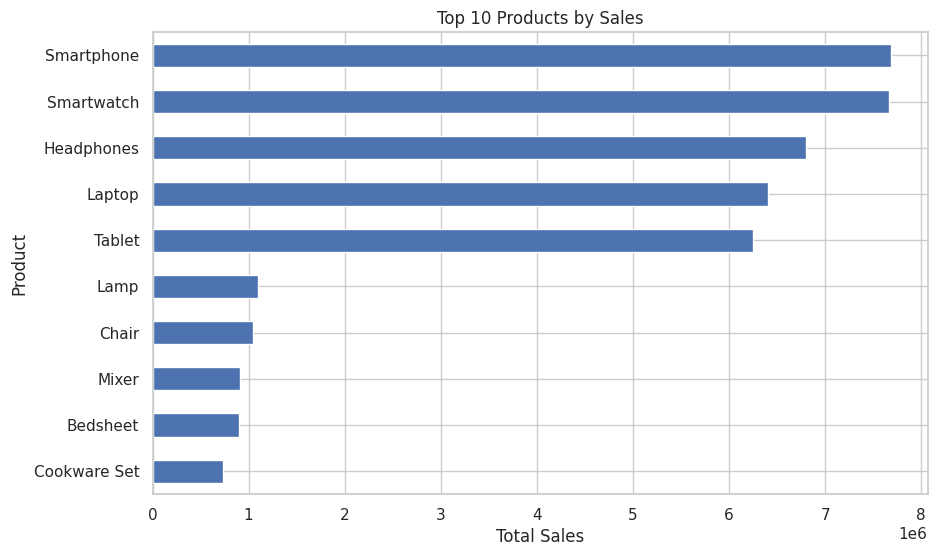

Product
Smartphone      7681817.05
Smartwatch      7668533.15
Headphones      6805104.85
Laptop          6400692.44
Tablet          6247384.08
Lamp            1093972.42
Chair           1048318.85
Mixer            912584.13
Bedsheet         897664.29
Cookware Set     734489.07
Name: Sales, dtype: float64


In [45]:
top_products = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()

print(top_products)

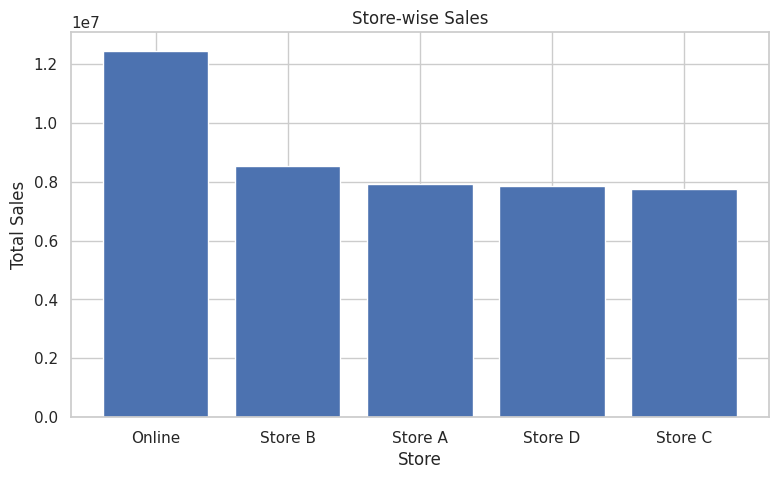

In [46]:
store_sales = (
    df.groupby("Store")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

plt.bar(store_sales.index, store_sales.values)

plt.title("Store-wise Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.show()

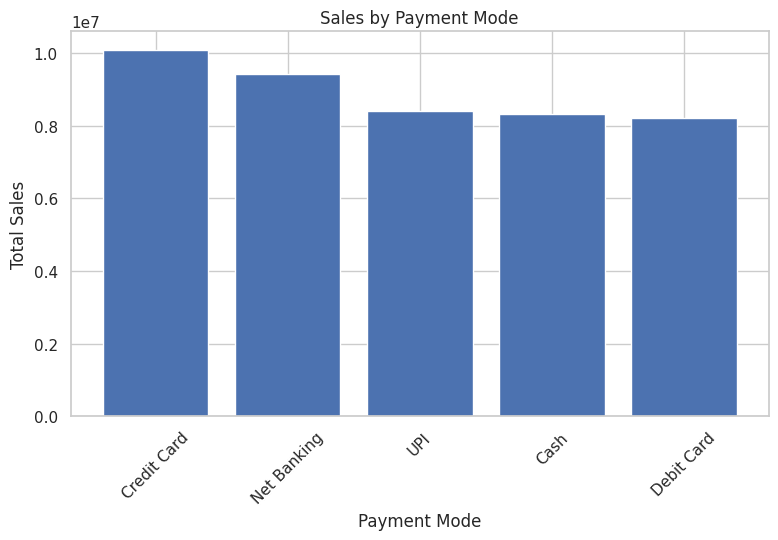

In [47]:
payment_sales = (
    df.groupby("Payment_Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

plt.bar(payment_sales.index, payment_sales.values)

plt.title("Sales by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

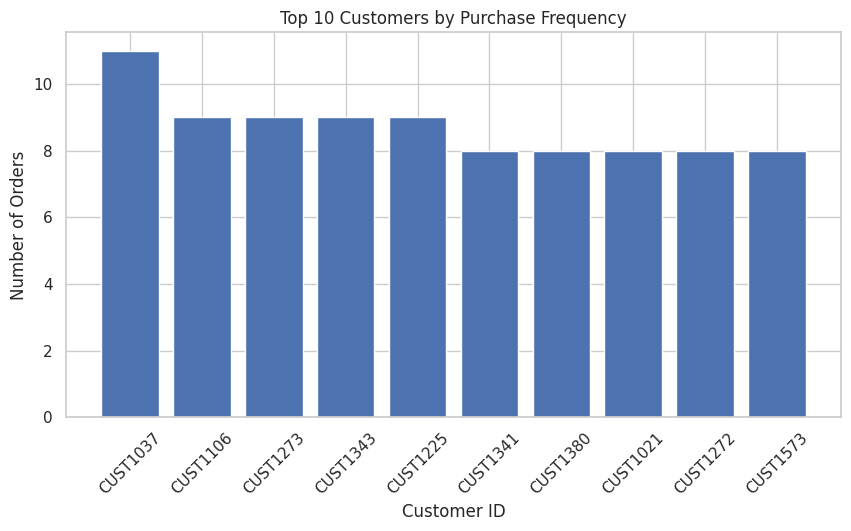

In [48]:
customer_frequency = (
    df["Customer_ID"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    customer_frequency.index.astype(str),
    customer_frequency.values
)

plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [49]:
top_customers = (
    df.groupby("Customer_ID")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Customers by Sales:")
print(top_customers)

Top 10 Customers by Sales:
Customer_ID
CUST1037    606765.44
CUST1189    545698.17
CUST1181    510666.76
CUST1161    427788.40
CUST1280    339363.93
CUST1431    333721.43
CUST1246    325330.60
CUST1175    316557.53
CUST1085    313655.02
CUST1445    311350.03
Name: Sales, dtype: float64


In [50]:
average_order_value = df["Sales"].mean()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 22237.77


In [51]:
sales_correlation = (
    df.select_dtypes(include=np.number)
    .corr()["Sales"]
    .sort_values(ascending=False)
)

print("Correlation with Sales:")
print(sales_correlation)

Correlation with Sales:
Sales              1.000000
Cost               0.999593
Profit             0.995709
Unit_Price         0.852822
Quantity           0.258663
Age                0.057463
Delivery_Days      0.014274
Customer_Rating    0.004816
Discount          -0.031529
Name: Sales, dtype: float64


In [52]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

sales_corr = (
    correlation_matrix["Sales"]
    .drop("Sales")
    .abs()
    .sort_values(ascending=False)
)

print("Strongest correlations with Sales:")
print(sales_corr)

Strongest correlations with Sales:
Cost               0.999593
Profit             0.995709
Unit_Price         0.852822
Quantity           0.258663
Age                0.057463
Discount           0.031529
Delivery_Days      0.014274
Customer_Rating    0.004816
Name: Sales, dtype: float64


In [53]:
print("========== BUSINESS SUMMARY ==========")

print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Quantity Sold:", df["Quantity"].sum())

print(
    "Top Category:",
    df.groupby("Category")["Sales"].sum().idxmax()
)

print(
    "Top Product:",
    df.groupby("Product")["Sales"].sum().idxmax()
)

print(
    "Top Store:",
    df.groupby("Store")["Sales"].sum().idxmax()
)

print(
    "Top City:",
    df.groupby("City")["Sales"].sum().idxmax()
)

print(
    "Most Used Payment Mode:",
    df["Payment_Mode"].value_counts().idxmax()
)

print(
    "Average Order Value:",
    round(df["Sales"].mean(), 2)
)

========== BUSINESS SUMMARY ==========
Total Sales: 44475539.26
Total Profit: 11491891.13
Total Quantity Sold: 8005
Top Category: Electronics
Top Product: Smartphone
Top Store: Online
Top City: Mumbai
Most Used Payment Mode: Debit Card
Average Order Value: 22237.77


In [54]:
df["Year"] = df["Date"].dt.year
df["Month_Number"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

print(df[[
    "Date",
    "Year",
    "Month_Number",
    "Day"
]].head())

        Date  Year  Month_Number  Day
0 2024-01-01  2024             1    1
1 2024-01-01  2024             1    1
2 2024-01-01  2024             1    1
3 2024-01-02  2024             1    2
4 2024-01-02  2024             1    2


In [55]:
features = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Discount",
    "Customer_Rating",
    "Delivery_Days",
    "Year",
    "Month_Number",
    "Day",
    "Gender",
    "City",
    "Region",
    "Store",
    "Category",
    "Product",
    "Payment_Mode"
]

X = df[features]
y = df["Sales"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (2000, 16)
Target: (2000,)


In [56]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded Features:", X.shape)

Encoded Features: (2000, 54)


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1600, 54)
Testing data: (400, 54)


In [58]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [59]:
linear_pred = linear_model.predict(X_test)

print("First 10 predictions:")
print(linear_pred[:10])

First 10 predictions:
[ -1518.98132355  12624.16849755  86615.93196165   6117.10419976
 -13355.87848585   8048.17937663  73366.8627869   23919.17999261
  -4899.4809564   13678.28410096]


In [63]:
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear Regression")
print("-----------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

Linear Regression
-----------------
MAE : 12022.41
RMSE: 17970.9
R²  : 0.7763


In [64]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [65]:
rf_pred = rf_model.predict(X_test)

print("First 10 predictions:")
print(rf_pred[:10])

First 10 predictions:
[  5515.89255   2776.68965 107315.81905   5428.37475   2286.76675
   3060.604    88882.8363   16227.6565    1141.9134    6630.10375]


In [66]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Regression")
print("------------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest Regression
------------------------
MAE : 1226.33
RMSE: 3187.09
R²  : 0.993


In [67]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,12022.414995,17970.899781,0.776266
1,Random Forest Regression,1226.333194,3187.091985,0.992963


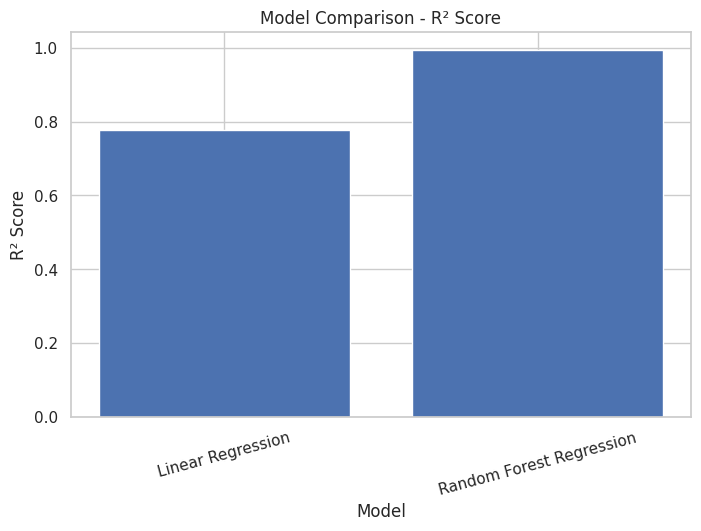

In [68]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"]
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)
plt.show()

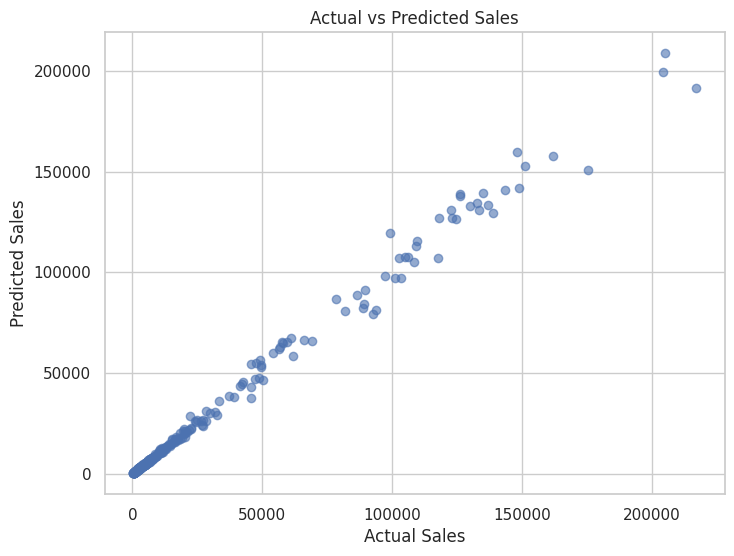

In [69]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.6
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

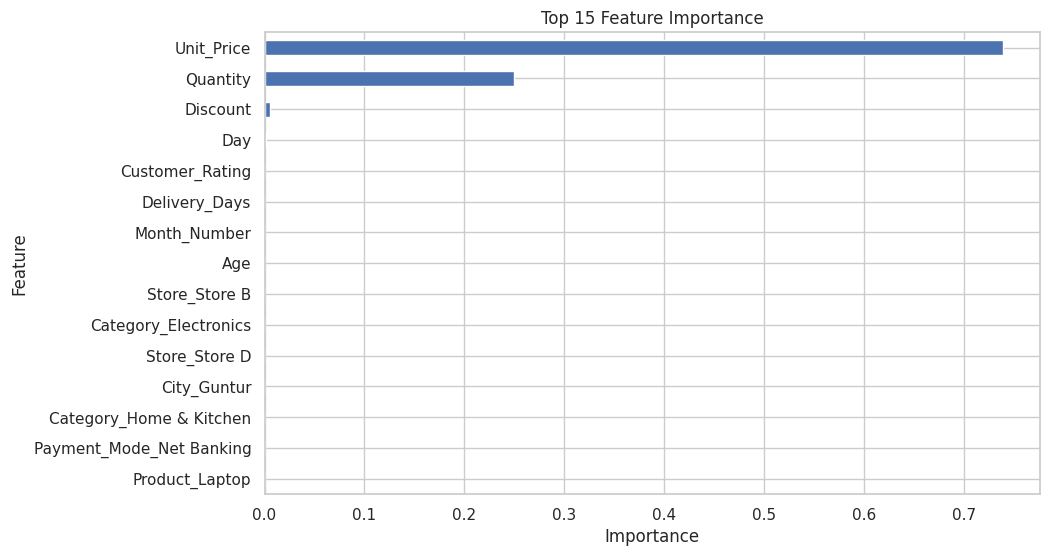

In [70]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [71]:
print("======================================")
print("          FINAL PROJECT RESULTS")
print("======================================")

print("\nDataset")
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nBusiness Analysis")
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Average Order Value:", round(df["Sales"].mean(), 2))

print("\nLinear Regression")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

print("\nRandom Forest Regression")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

          FINAL PROJECT RESULTS

Dataset
Rows: 2000
Columns: 23

Business Analysis
Total Sales: 44475539.26
Total Profit: 11491891.13
Average Order Value: 22237.77

Linear Regression
MAE : 12022.41
RMSE: 17970.9
R²  : 0.7763

Random Forest Regression
MAE : 1226.33
RMSE: 3187.09
R²  : 0.993



## Business Insights

The analysis shows that sales performance depends on multiple factors such as product category, quantity, pricing, discounts, customer behavior, and location.

High sales volume does not always mean high profitability, so the business should focus on both sales and profit margins when making decisions.

Product- and category-level analysis can help identify strong performers and products that need improvement.

Customer purchase patterns can be used to identify valuable customers and improve customer retention strategies.

Discount analysis can help the business find a balance between increasing sales and maintaining profitability.

Store, city, and regional analysis can help identify strong markets and areas that need additional attention.

Overall, these insights can support better decisions related to pricing, promotions, inventory management, customer retention, and sales strategy.


## Conclusion

This project analyzed retail sales data using Python, Pandas, NumPy, Matplotlib, and Seaborn.

The project included data cleaning, statistical analysis using mean, median, mode, variance, standard deviation, quartiles, and IQR, along with extensive exploratory data analysis.

Different visualizations such as bar charts, pie charts, line graphs, scatter plots, box plots, and heatmaps were used to identify important patterns and relationships in the data.

Finally, Linear Regression and Random Forest Regression were applied for sales prediction and evaluated using MAE, RMSE, and R² Score.

The project demonstrates how data analysis and machine learning can be combined to understand retail performance and support data-driven business decision-making.
```
```

